# Exploratory Data Analysis: Telco Customer Churn

This notebook profiles the Telco Customer Churn CSV before model training. It examines target balance, feature distributions, data quality, and relationships with churn. All results are descriptive; observed associations are not interpreted as causal.

In [11]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

DATA_PATH = DATA_PATH.resolve()
PROJECT_ROOT = DATA_PATH.parent.parent
GRAPHICS_DIR = PROJECT_ROOT / "docs" / "graphics"
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Source: {DATA_PATH}")


print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())
print("Datatype from TotalCharges, is realy a float64, but has 11 exception values not value")
display(df.dtypes.rename("data type").to_frame())

Source: C:\Users\Usuario\Desktop\Materias\ML\Final Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Datatype from TotalCharges, is realy a float64, but has 11 exception values not value


,data type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


## Target distribution

The target is `Churn`, with `Yes` denoting customers who left and `No` denoting customers who stayed. The class counts, percentages, and majority-to-minority ratio quantify the imbalance.

,customers,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


Majority-to-minority ratio: 2.77:1


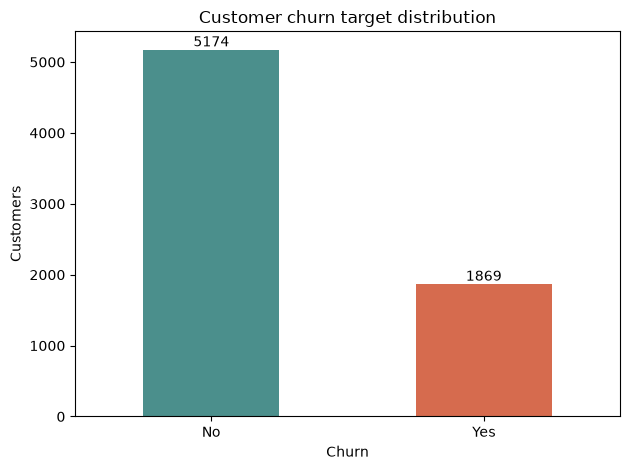

In [12]:
import matplotlib.pyplot as plt

target_counts = df["Churn"].value_counts().reindex(["No", "Yes"])
target_percentages = target_counts / len(df) * 100
imbalance_ratio = target_counts.max() / target_counts.min()

display(pd.DataFrame({"customers": target_counts, "percent": target_percentages.round(2)}))
print(f"Majority-to-minority ratio: {imbalance_ratio:.2f}:1")

ax = target_counts.plot(kind="bar", color=["#4b8f8c", "#d66b4e"], rot=0)
ax.set(title="Customer churn target distribution", xlabel="Churn", ylabel="Customers")
ax.bar_label(ax.containers[0], fmt="%d")
plt.tight_layout()
plt.show()

## Numerical feature statistics

`SeniorCitizen` is binary; `tenure`, `MonthlyCharges`, and parsed `TotalCharges` are summarized with count, mean, standard deviation, minimum, and maximum. `TotalCharges` is converted to numeric for analysis without modifying the original dataframe.

,count,mean,std,min,max
tenure,7043.0,32.37,24.56,0.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,8684.80


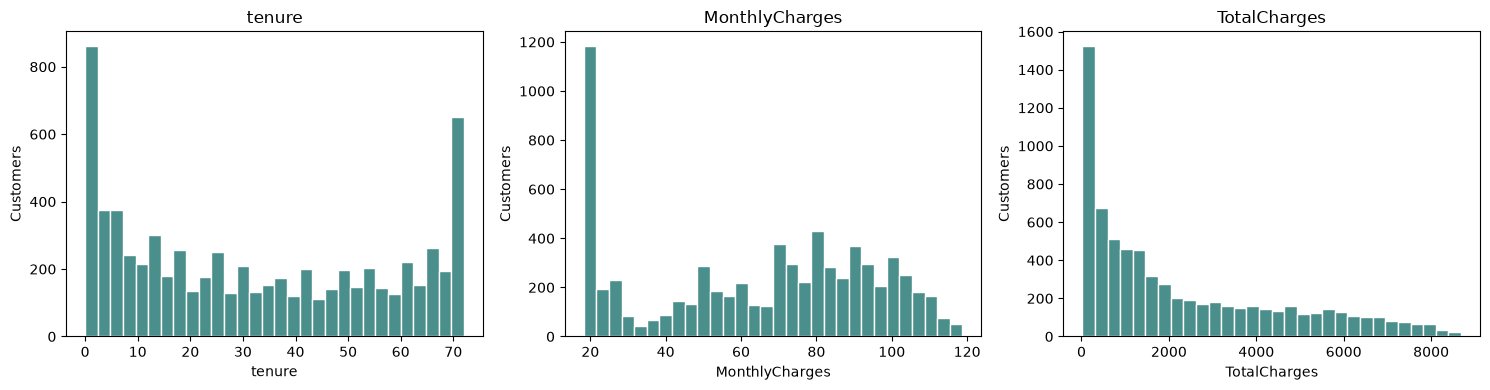

In [13]:
numeric = df[["tenure", "MonthlyCharges"]].copy()
numeric["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

summary = numeric.describe().T[["count", "mean", "std", "min", "max"]]
display(summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    numeric[column].dropna().plot(kind="hist", bins=30, ax=axis, color="#4b8f8c", edgecolor="white")
    axis.set(title=column, xlabel=column, ylabel="Customers")
plt.tight_layout()
fig.savefig(GRAPHICS_DIR / "numeric_feature_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Categorical feature distributions

For each categorical feature, plot the percentage of all customer records in each value. `customerID` is excluded because it is a unique identifier, and `Churn` is already plotted in the target section. The binary `SeniorCitizen` feature is included as a category. Features are grouped three per image for readability; the last image contains the remaining feature.

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_01_customer_profile.png


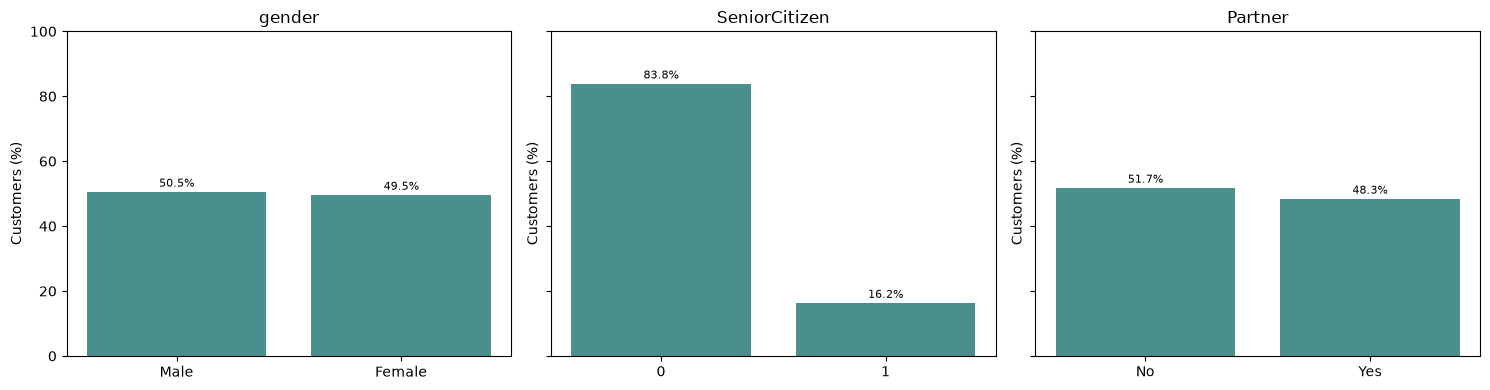

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_02_phone_services.png


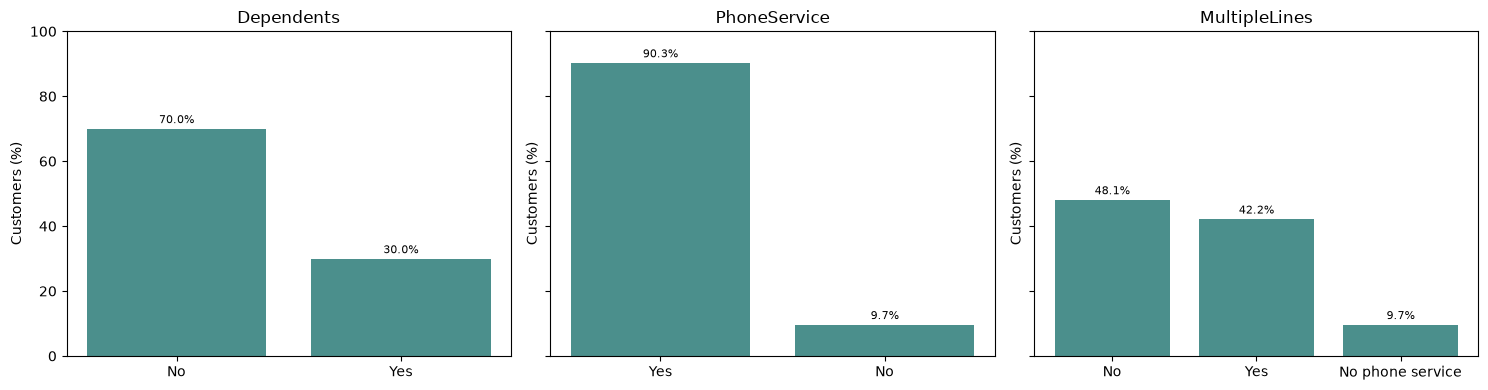

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_03_internet_and_security.png


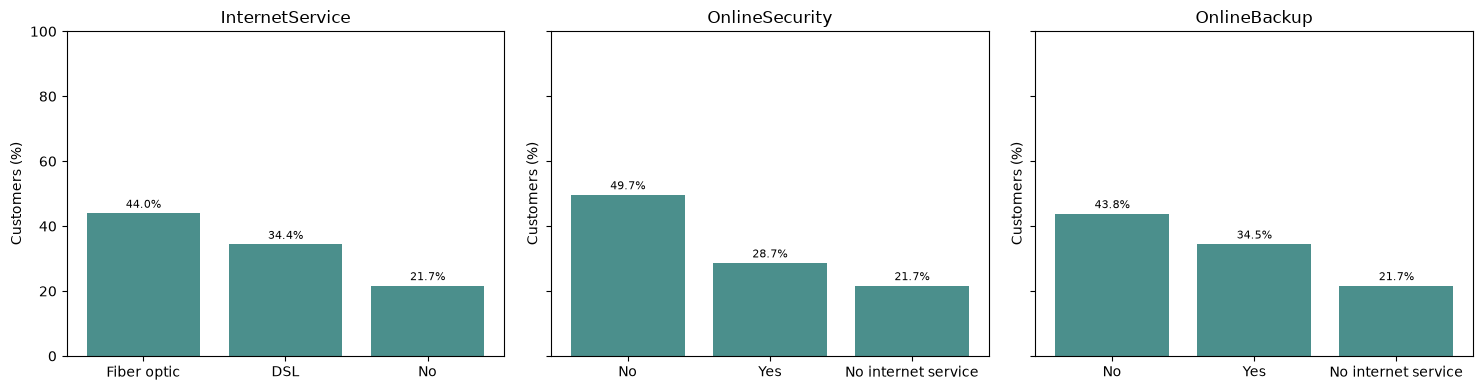

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_04_protection_and_support.png


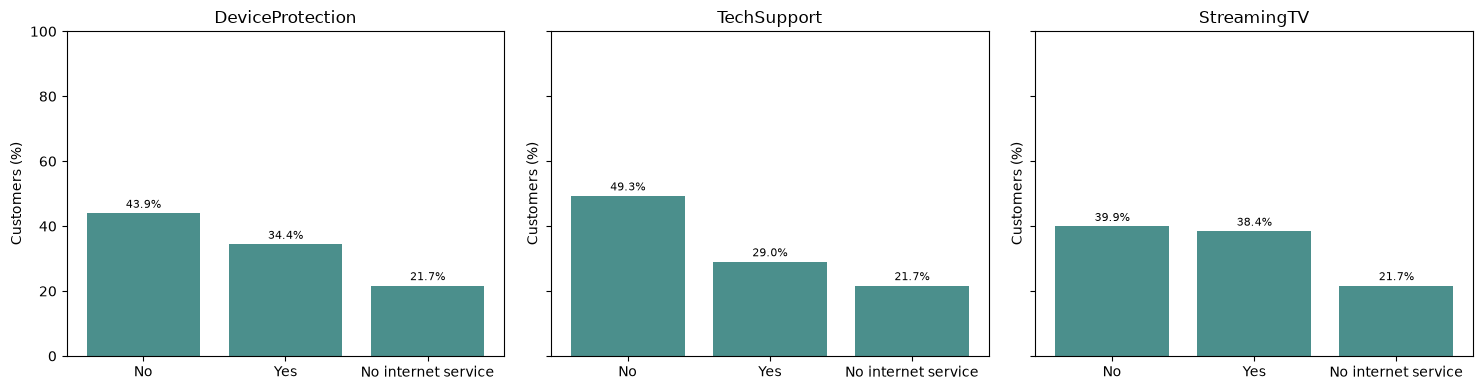

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_05_streaming_and_contract.png


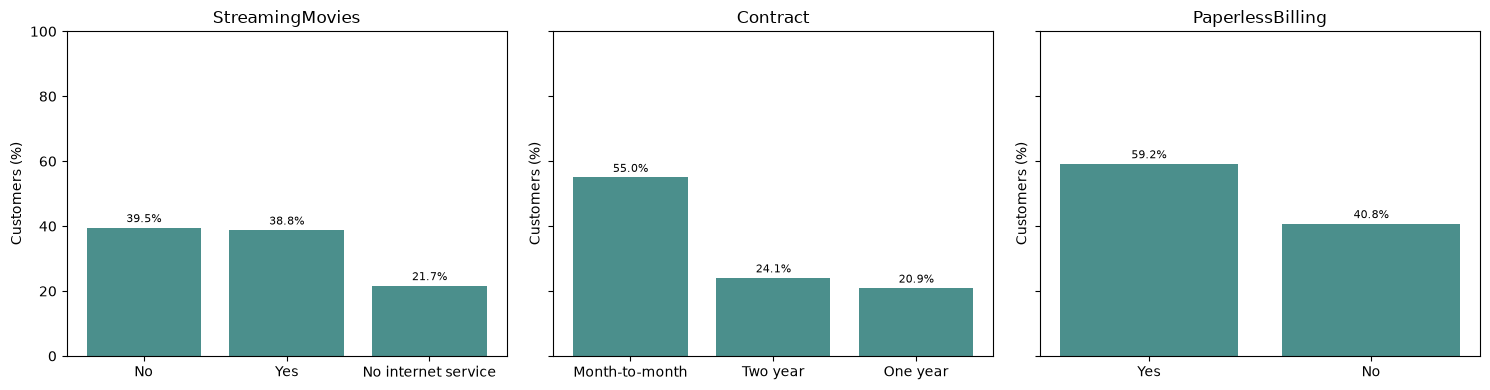

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\categorical_distributions_06_payment_method.png


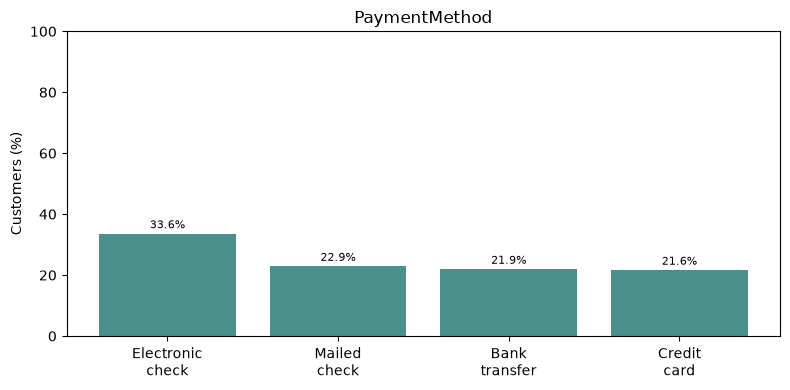

In [20]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]
figure_groups = [
    (categorical_features[index:index + 3], filename)
    for index, filename in zip(
        range(0, len(categorical_features), 3),
        [
            "categorical_distributions_01_customer_profile.png",
            "categorical_distributions_02_phone_services.png",
            "categorical_distributions_03_internet_and_security.png",
            "categorical_distributions_04_protection_and_support.png",
            "categorical_distributions_05_streaming_and_contract.png",
            "categorical_distributions_06_payment_method.png",
        ],
    )
 ]

for features, filename in figure_groups:
    figure_width = 8 if features == ["PaymentMethod"] else 5 * len(features)
    fig, axes = plt.subplots(1, len(features), figsize=(figure_width, 4), squeeze=False, sharey=True)
    for axis, feature in zip(axes.flat, features):
        percentages = df[feature].value_counts(dropna=False) / len(df) * 100
        if feature == "PaymentMethod":
            graph_labels = [
                label.replace(" (automatic)", "").replace(" ", "\n", 1)
                for label in percentages.index.astype(str)
            ]
            bars = axis.bar(
                graph_labels,
                percentages.values,
                color="#4b8f8c",
            )
            axis.set_xlabel("")
            axis.set_ylabel("Customers (%)")
            axis.set_ylim(0, 100)
            axis.tick_params(axis="x", labelrotation=0)
        else:
            bars = axis.bar(
                percentages.index.astype(str),
                percentages.values,
                color="#4b8f8c",
            )
            axis.set_xlabel("")
            axis.set_ylabel("Customers (%)")
            axis.set_ylim(0, 100)
            axis.tick_params(axis="x", labelrotation=0)
        axis.set_title(feature)
        axis.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)

    fig.tight_layout()
    output_path = GRAPHICS_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()
    plt.close(fig)

## Data quality and unusual values

Check missing values, blank or non-numeric `TotalCharges`, duplicate rows, and uniqueness of `customerID`. Use the 1.5-IQR rule to flag potential numeric outliers; these flags identify values for review, not necessarily errors.

In [7]:
total_charges = df["TotalCharges"].astype("string")
parsed_total_charges = pd.to_numeric(total_charges, errors="coerce")
blank_total_charges = total_charges.str.strip().eq("")
quality = {
    "rows": len(df),
    "native_missing_cells": int(df.isna().sum().sum()),
    "blank_TotalCharges": int(blank_total_charges.sum()),
    "unparseable_TotalCharges": int(parsed_total_charges.isna().sum()),
    "blank_TotalCharges_with_tenure_zero": int((blank_total_charges & df["tenure"].eq(0)).sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "unique_customerIDs": int(df["customerID"].nunique()),
}
display(pd.Series(quality, name="value").to_frame())

iqr_rows = []
for column in ["tenure", "MonthlyCharges", "TotalCharges"]:
    values = numeric[column].dropna()
    lower_quartile, upper_quartile = values.quantile([0.25, 0.75])
    iqr = upper_quartile - lower_quartile
    lower_fence = lower_quartile - 1.5 * iqr
    upper_fence = upper_quartile + 1.5 * iqr
    flagged = values.lt(lower_fence) | values.gt(upper_fence)
    iqr_rows.append({
        "feature": column,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "flagged_count": int(flagged.sum()),
        "flagged_percent": flagged.mean() * 100,
    })
display(pd.DataFrame(iqr_rows).round(2))

assert quality["rows"] == 7043
assert quality["blank_TotalCharges"] == 11
assert quality["duplicate_rows"] == 0
assert quality["unique_customerIDs"] == len(df)

,value
rows,7043
native_missing_cells,0
blank_TotalCharges,11
unparseable_TotalCharges,11
blank_TotalCharges_with_tenure_zero,11
duplicate_rows,0
unique_customerIDs,7043


,feature,lower_fence,upper_fence,flagged_count,flagged_percent
0,tenure,-60.00,124.00,0,0.0
1,MonthlyCharges,-46.02,171.38,0,0.0
2,TotalCharges,-4688.48,8884.67,0,0.0


## Feature relationships with churn

Compare churn rates across selected service and contract categories, and compare tenure and monthly charges by target class. These conditional percentages are descriptive and do not establish causation.

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_numeric_feature_relationships.png


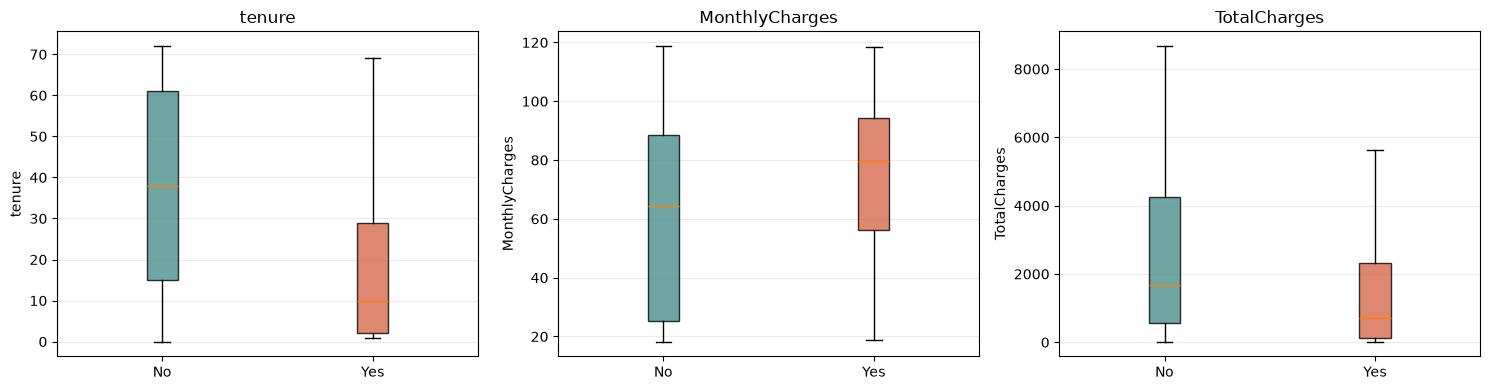

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_01_customer_profile.png


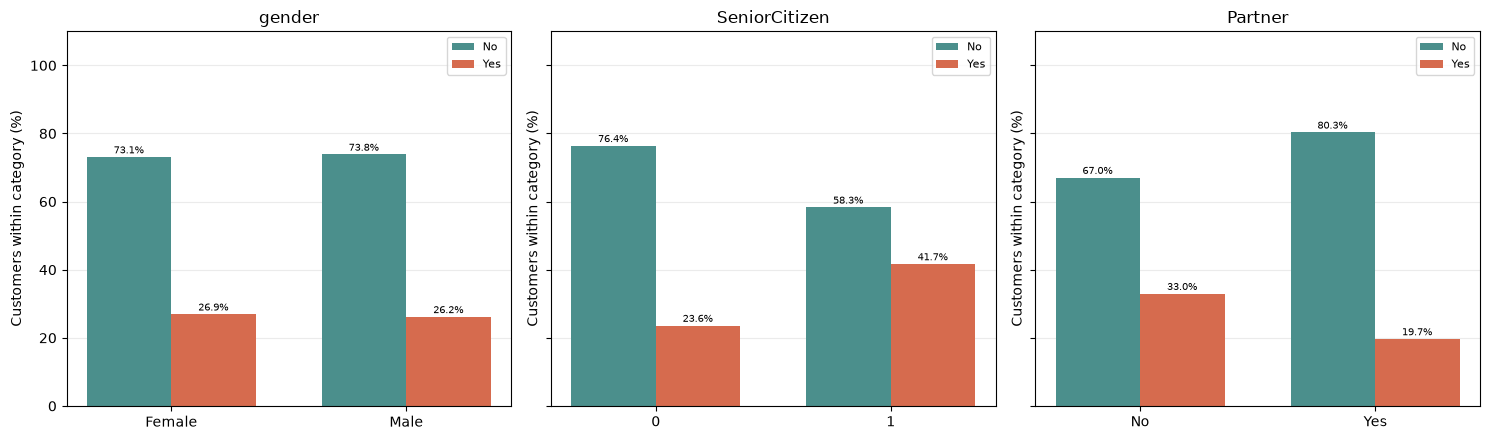

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_02_household_phone.png


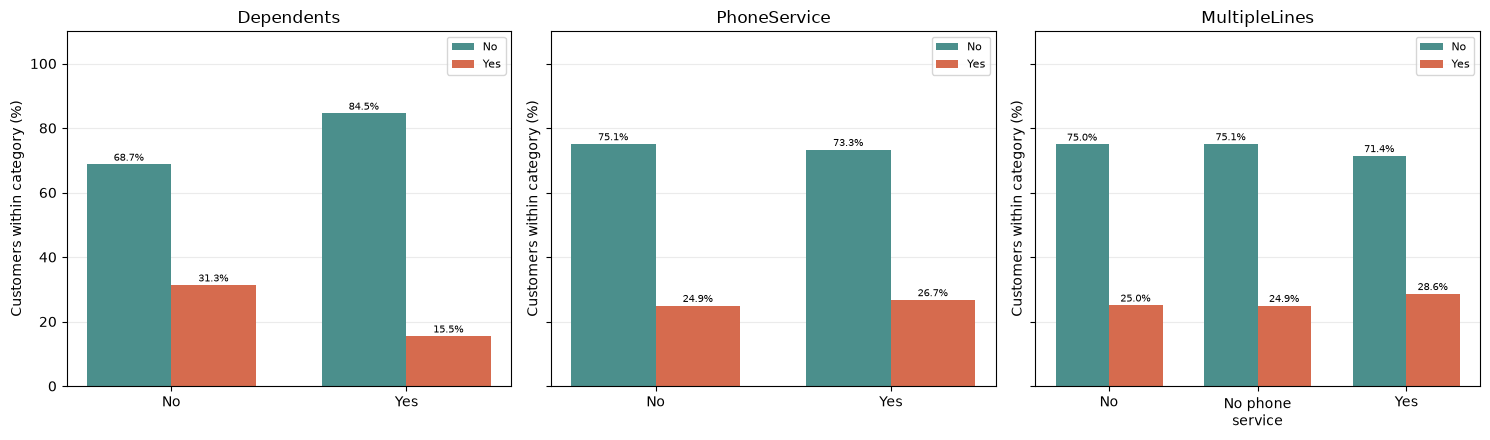

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_03_internet_security.png


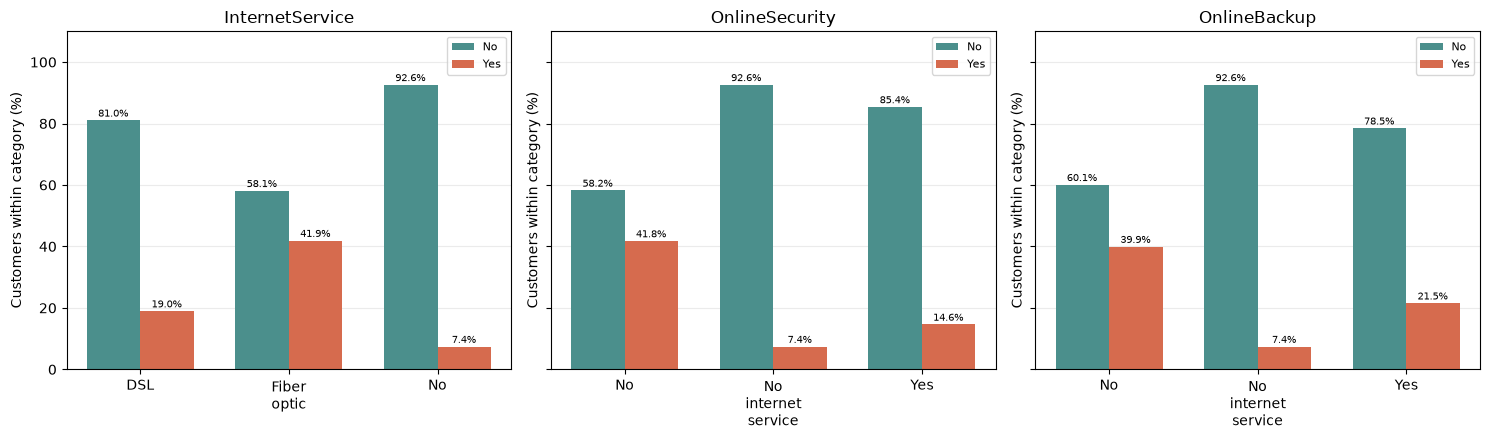

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_04_protection_support.png


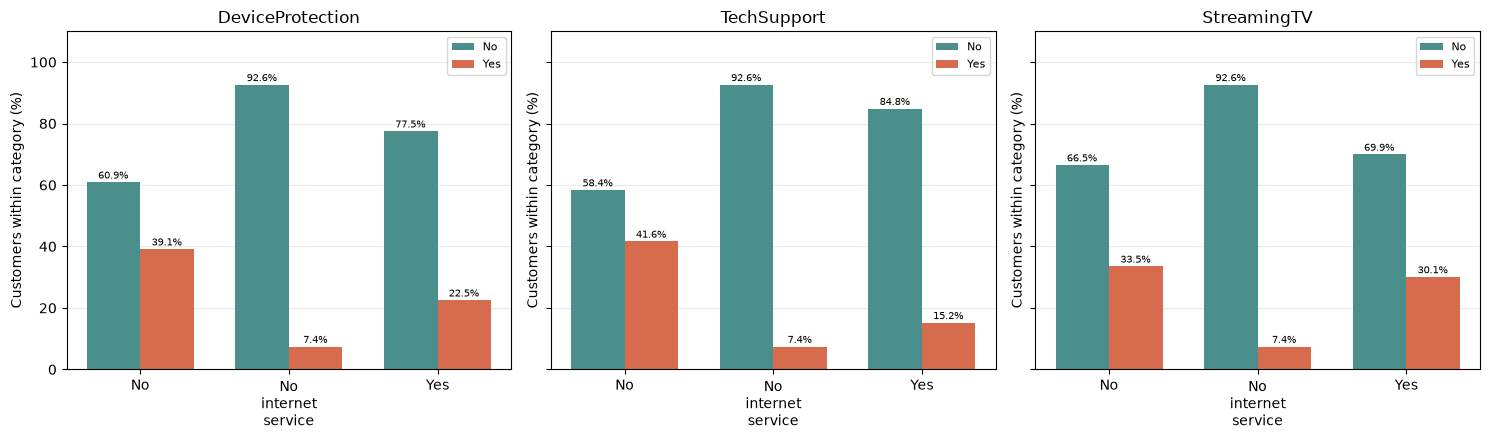

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_05_streaming_contract.png


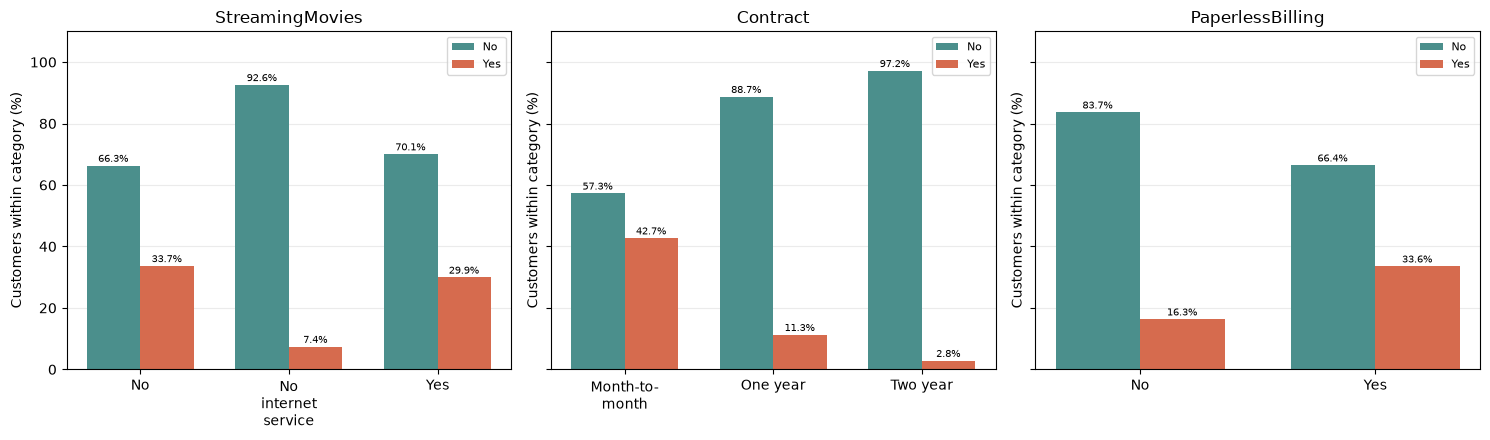

Saved: C:\Users\Usuario\Desktop\Materias\ML\Final Project\docs\graphics\churn_categorical_relationships_06_payment_method.png


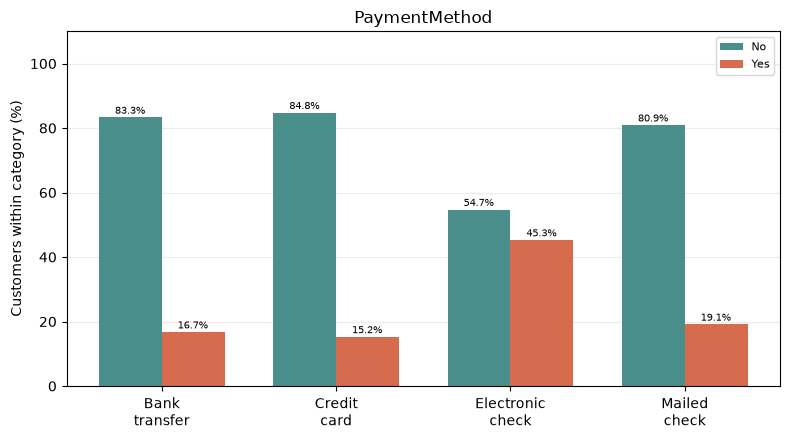

In [22]:
import textwrap

import numpy as np

churn_labels = ["No", "Yes"]
numeric_relationship_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
churn_colors = ["#4b8f8c", "#d66b4e"]
for axis, feature in zip(axes, numeric_relationship_features):
    class_values = [
        numeric.loc[df["Churn"].eq(label), feature].dropna().to_numpy()
        for label in churn_labels
    ]
    boxplots = axis.boxplot(class_values, patch_artist=True, showfliers=False)
    for box, color in zip(boxplots["boxes"], churn_colors):
        box.set_facecolor(color)
        box.set_alpha(0.8)
    axis.set_xticks([1, 2], labels=churn_labels)
    axis.set_title(feature)
    axis.set_ylabel(feature)
    axis.grid(axis="y", alpha=0.25)

fig.tight_layout()
numeric_output = GRAPHICS_DIR / "churn_numeric_feature_relationships.png"
fig.savefig(numeric_output, dpi=300, bbox_inches="tight")
print(f"Saved: {numeric_output}")
plt.show()
plt.close(fig)

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]
categorical_figure_groups = [
    (categorical_features[index:index + 3], filename)
    for index, filename in zip(
        range(0, len(categorical_features), 3),
        [
            "churn_categorical_relationships_01_customer_profile.png",
            "churn_categorical_relationships_02_household_phone.png",
            "churn_categorical_relationships_03_internet_security.png",
            "churn_categorical_relationships_04_protection_support.png",
            "churn_categorical_relationships_05_streaming_contract.png",
            "churn_categorical_relationships_06_payment_method.png",
        ],
    )
 ]

for features, filename in categorical_figure_groups:
    figure_width = 8 if features == ["PaymentMethod"] else 5 * len(features)
    fig, axes = plt.subplots(
        1,
        len(features),
        figsize=(figure_width, 4.5),
        squeeze=False,
        sharey=True,
    )
    for axis, feature in zip(axes.flat, features):
        rates = pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index",
        ).reindex(columns=churn_labels, fill_value=0) * 100
        positions = np.arange(len(rates.index))
        bar_width = 0.36
        no_bars = axis.bar(
            positions - bar_width / 2,
            rates["No"],
            bar_width,
            label="No",
            color=churn_colors[0],
        )
        yes_bars = axis.bar(
            positions + bar_width / 2,
            rates["Yes"],
            bar_width,
            label="Yes",
            color=churn_colors[1],
        )
        labels = [
            textwrap.fill(
                str(value).replace(" (automatic)", ""),
                width=10,
                break_long_words=False,
            )
            for value in rates.index
        ]
        axis.set_xticks(positions, labels=labels, rotation=0)
        axis.set_title(feature)
        axis.set_ylabel("Customers within category (%)")
        axis.set_ylim(0, 110)
        axis.grid(axis="y", alpha=0.25)
        axis.set_axisbelow(True)
        axis.bar_label(no_bars, fmt="%.1f%%", padding=1, fontsize=7)
        axis.bar_label(yes_bars, fmt="%.1f%%", padding=1, fontsize=7)
        axis.legend(fontsize=8)

    fig.tight_layout()
    output_path = GRAPHICS_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_path}")
    plt.show()
    plt.close(fig)

## Findings

The dataset has an imbalanced target: 5,174 customers stayed (73.46%) and 1,869 churned (26.54%), a 2.77:1 ratio. The 11 blank `TotalCharges` entries (0.16% of rows) all belong to customers with zero tenure; the project preprocessing treats these as zero charges. There are no duplicate rows, and every `customerID` is unique. Potential IQR outliers should be reviewed rather than removed automatically.

Churn is more common among month-to-month customers (42.7%) than one-year (11.3%) or two-year contract customers (2.8%). The observed churn rate is also higher for fiber-optic customers (41.9%) and electronic-check customers (45.3%). Customers who churned had lower median tenure (10 months versus 38) and higher mean monthly charges (74.44 versus 61.27). These are associations in this dataset, not causal effects.